# Session 2

## Index

1. Intended learning outcomes
2. Histograms
3. Plotting error bars
4. Line fitting
5. Optional: other fitting models

## 1. Intended learning outcomes<a id="outcomes"></a>
After this session, you should be able to:
- plot a histogram of a 1D data set;
- plot error bars on scatter plots;
- fit a linear model to your data and plot both fit and data;
- find the uncertainties on your fit parameters.

## 2. Histograms<a id="histograms"></a>

<div style="background-color: #00FF00">
** Exercise 1: before you move on, import the relevant packages for plotting and scientific calculations and below. Which will you need?**

In [8]:
import scipy as sp
import matplotlib.pyplot as plt

In [9]:
data = sp.loadtxt('Data/Dataset.txt')# read the data from file
plt.ylabel("Number of measurements")# set the y-label
plt.xlabel("Speed (m/s)")# set the x-label
plt.hist(data)# create a histogram of the data
plt.show()# show the plot

<ipython-input-9-900e05380885>:1: DeprecationWarning: scipy.loadtxt is deprecated and will be removed in SciPy 2.0.0, use numpy.loadtxt instead
  data = sp.loadtxt('Data/Dataset.txt')# read the data from file


OSError: Data/Dataset.txt not found.

<div style="background-color: #00FF00">

**Exercise 2: inspect the data and calculate the mean and standard deviation of the entire sample to get an idea of how far away the point is. Would it be reasonable to assume a mistake was made in this measurement?**

In [ ]:
print(data)
mean=sp.mean(data)
std=sp.std(data,ddof=1)
print("Mean of original data: "+str(mean))
print("Std of original data: "+str(std))

In [ ]:
clean_data=sp.delete(data,5)
print(clean_data)

<div style="background-color: #00FF00">
**Exercise 3: recalculate the mean and standard deviation, and display a histogram of the new data sample. Has the result changed?**

In [ ]:
mean_2=sp.mean(clean_data)
std_2=sp.std(clean_data,ddof=1)
print("Mean of cleaned data: "+str(mean_2))
print("Mean of cleaned data: "+str(std_2))
plt.hist(clean_data)
plt.ylabel("Number of measurements")# set the y-label
plt.xlabel("Speed (m/s)")# set the x-label

<div style="background-color: #FFF8C6">

**Exercise: Use the <span style="color:blue">plt.subplot()</span> function to plot the two histograms you created above side by side.**

In [ ]:
plt.figure(figsize=(6,6)) # set the size of the figure
plt.subplot(1,2,1)
plt.hist(data)
plt.ylabel("Number of measurements")# set the y-label
plt.xlabel("Speed (m/s)")# set the x-label
plt.subplot(1,2,2)
plt.hist(clean_data)
plt.ylabel("Number of measurements")# set the y-label
plt.xlabel("Speed (m/s)")# set the x-label
plt.tight_layout() # formatting label to spread out graphs

<div style="background-color: #FFF8C6">
**Exercise: read the data stored in the file [five_datasets.txt](https://cclewley.github.io/ComputingYr1/Data2/five_datasets.txt) (in the 'Data' folder) into Python. Next, for each dataset, plot a histogram and calculate the mean and standard deviation. Do the means of each set of data come out close to each other?  Are the standard deviations of each set the same?  What is the standard error of the mean of each set?  Are the differences between the means of all the sets similar to the values of the calculated standard errors?**


In [13]:
data_histogram=sp.loadtxt('Data/five_datasets.txt',skiprows=1)
plt.figure(figsize=(10,10))
plt.subplot(2,3,1)
plt.hist(data_histogram[:,0])
mean_set1=sp.mean(data_histogram[:,0])
print("Mean of set 1: " + str(mean_set1))
std_set1=sp.std(data_histogram[:,0],ddof=1)
print("Std of set 1: " + str(std_set1))
sterr_set1=std_set1/sp.sqrt(20)
print("Standard error of set 1: " + str(sterr_set1))

plt.subplot(2,3,2)
plt.hist(data_histogram[:,1])
mean_set2=sp.mean(data_histogram[:,1])
print("Mean of set 2: " + str(mean_set2))
std_set2=sp.std(data_histogram[:,1],ddof=1)
print("Std of set 2: " + str(std_set2))
sterr_set2=std_set2/sp.sqrt(20)
print("Standard error of set 2: " + str(sterr_set2))

plt.subplot(2,3,3)
plt.hist(data_histogram[:,2])
mean_set3=sp.mean(data_histogram[:,2])
print("Mean of set 3: " + str(mean_set3))
std_set3=sp.std(data_histogram[:,2],ddof=1)
print("Std of set 3: " + str(std_set3))
sterr_set3=std_set3/sp.sqrt(20)
print("Standard error of set 3: " + str(sterr_set3))

plt.subplot(2,3,4)
plt.hist(data_histogram[:,3])
mean_set4=sp.mean(data_histogram[:,3])
print("Mean of set 4: " + str(mean_set4))
std_set4=sp.std(data_histogram[:,3],ddof=1)
print("Std of set 4: " + str(std_set4))
sterr_set4=std_set4/sp.sqrt(20)
print("Standard error of set 4: " + str(sterr_set4))

plt.subplot(2,3,5)
plt.hist(data_histogram[:,4])
mean_set5=sp.mean(data_histogram[:,4])
print("Mean of set 5: " + str(mean_set5))
std_set5=sp.std(data_histogram[:,4],ddof=1)
print("Std of set 5: " + str(std_set5))
sterr_set5=std_set5/sp.sqrt(20)
print("Standard error of set 5: " + str(sterr_set5))

plt.tight_layout()

<ipython-input-13-848c3a399085>:1: DeprecationWarning: scipy.loadtxt is deprecated and will be removed in SciPy 2.0.0, use numpy.loadtxt instead
  data_histogram=sp.loadtxt('Data/five_datasets.txt',skiprows=1)


OSError: Data/five_datasets.txt not found.

<div style="background-color: #FFF8C6">
Now we will investigate what happens when we combine the five datasets into one dataset of 100 measurements.
<p>
** Exercise: plot a histogram of the combined dataset (including all 100 measurements) and calculate the mean, standard deviation, and standard error of the mean. Compare this to the results from the individual datasets comprising 20 measurements. What is the difference? Write your combined dataset to a file (i.e. one column with 100 data points) and save your final histogram. Remember to save all your output in the 'Output' folder!**

Hint: you can flatten a 2D-array into a 1D-array by using the <span style="color:blue">flatten()</span> function. For example, the following line of code would flatten a (pre-existing) 2D array called 'data_array' and store it into a 1D array called 'new_1Darray':

```python
new_1Darray = data_array.flatten()
```
<span style="color:#FFF8C6">.</span>

In [ ]:
data_histogram_flatten=data_histogram.flatten()
mean_wholeset=sp.mean(data_histogram_flatten)
print("Mean of whole dataset: " + str(mean_wholeset))
std_wholeset=sp.std(data_histogram_flatten,ddof=1)
print("std of whole dataset: " + str(std_wholeset))
sterr_wholeset=std_wholeset/10
print("standard error of whole dataset: " + str(sterr_wholeset))
plt.hist(data_histogram_flatten)

## 3. Plotting error bars<a id="errorbars"></a>
<div style="background-color: #00FF00">
** Exercise 4: have a look at the help for the <span style="color:blue">errorbar()</span> function to see which input arguments it takes. Pay particular attention to the keywords <span style="color:blue">yerr</span>, which takes an array that includes the y-error bars, and <span style="color:blue">fmt</span>, with which you specify the plotting symbol. **

** Exercise 5: load the resistivity data we used last session ([Resistivity.txt](https://cclewley.github.io/ComputingYr1/Data2/Resistivity.txt)) (included in this session's 'Data' folder), create an array containing 5% errors on the resistivity data, and plot a scatter plot of the data including error bars. **

Note: the exercise above includes little guidance - this is to help you get used to finding programming solutions to problems you have not encountered before. Start by looking through the help file, and possibly googling example uses of the function. Also feel free to discuss with your neighbours! If you still find you have trouble getting started (don't worry - this is normal for novice coders), skip ahead to the blue box below and after showing your previous results ask your demonstrator to help you on your way.

In [ ]:
help(plt.errorbar)

In [ ]:
Res_data=sp.loadtxt('Data/Resistivity.txt',skiprows=1)
R_Cu_err=0.05*Res_data[:,1]
R_Al_err=0.05*Res_data[:,2]

plt.errorbar(Res_data[:,0],Res_data[:,1],yerr=R_Cu_err,fmt='*',label='Cu')
plt.errorbar(Res_data[:,0],Res_data[:,2],yerr=R_Al_err,fmt='*',label='Al')
plt.legend()
plt.xlabel('Temperature (K)')
plt.ylabel('Resistivity $(\Omega  m)$')

<div style="background-color: #FFF8C6">
You can customise many features on your error bar plot. For example, can you find out how to put caps on your error bars (so they are displayed as **T** rather than **I**)? Also, your independent variable may have error bars too, which you would need to add to your plot. 

**Exercise: add fixed temperature error bars of 2K to your plot. Check the <span style="color:blue">errorbar()</span> documentation for this!**

In [ ]:
plt.errorbar(Res_data[:,0],Res_data[:,1],yerr=R_Cu_err,xerr=2,fmt='*',label='Cu')
plt.errorbar(Res_data[:,0],Res_data[:,2],yerr=R_Al_err,xerr=2,fmt='*',label='Al')
plt.legend()
plt.xlabel('Temperature (K)')
plt.ylabel('Resistivity $(\Omega  m)$')

<div style="background-color: #FFF8C6">
### Error bars on histograms
Sometimes we want to plot error bars on histograms. For example, if your histogram displays a number of counts of a certain value, you may want to add Poisson errors to each bin ($\sigma_{\rm Poisson} = \sqrt{N}$, where $N$ is the number of counts in the bin).

** Exercise (challenging): below, recreate the histogram you made in the previous section of the full dataset, and add Poisson error bars to each bin.** 

Tip: besides plotting a histogram, the matplotlib function <span style="color:blue">hist()</span> can return values too. Look this up, and use it to calculate and create the error bars with the <span style="color:blue">errorbar()</span> function. You will need to think carefully about the $x$-positions of the error bars!

In [ ]:
bins=plt.hist(data_histogram.flatten())# recreate our previous histogram and store the bins x and y values.
bincentres = 0.5*(bins[1][1:]+bins[1][:-1])# calculate the bin centres (i.e. x position of the error bars)
plt.errorbar(bincentres[0:10],bins[0],sp.sqrt(bins[0]),fmt=',',capsize=2)# plot the error bars.
plt.show()

## 4. Line fitting<a id="linefitting"></a>

In [ ]:
import scipy as sp
import matplotlib.pyplot as plt

T,R_Cu,R_Al = sp.loadtxt('Data/Resistivity.txt',unpack=True)# Read in the data
errors_Al = 0.05*R_Al# Calculate 5% errors
errors_Cu = 0.05*R_Cu

# The line below stores the fit coefficients in the fit_Al variable, and the covariance matrix in the cov_Al variable.
# Note that the input arguments for polyfit() below are:
# (1) the independent variable (T)
# (2) the dependent variable (R_Al)
# (3) the order of the polynomial to be fitted (1)
# (4) the weights of each data point (w = 1/errors_Al)
# (5) whether or not to return the covariance matrix (cov = True)
fit_Al,cov_Al = sp.polyfit(T,R_Al,1,w=1/errors_Al,cov=True)
print('Aluminium fit coefficients')
print(fit_Al)
print('covariance matrix')
print(cov_Al)

sig_0 = sp.sqrt(cov_Al[0,0]) #The uncertainty in the slope
sig_1 = sp.sqrt(cov_Al[1,1]) #The uncertainty in the intercept

print('Slope = %.3e +/- %.3e' %(fit_Al[0],sig_0))# Note the %.3e forces the values to be printed in scientific notation with 3 decimal places.
print('Intercept = %.3e +/- %.3e' %(fit_Al[1],sig_1))

In [ ]:
import scipy as sp
import matplotlib.pyplot as plt
% matplotlib inline

# Calculate the fit 
pAl=sp.poly1d(fit_Al)
print('Aluminium polynomial')
print(pAl)

# Create the original data figure with error bars
plt.grid()
plt.xlabel("Temperature (K)") 
plt.ylabel("Resistivity (Ohm m)") 
plt.title("Resistivity Plot") 
plt.errorbar(T,R_Cu,yerr=errors_Cu, fmt='o', mew=2, ms=3, capsize=4)
plt.errorbar(T,R_Al,yerr=errors_Al, fmt='o', mew=2, ms=3, capsize=4)
plt.legend(["Copper", "Aluminium"], loc=2 ) 
plt.xticks(sp.arange(200, 400, 50))

# Overlay the linear fit
# Note that we create the y-coordinates for the fit data points by calling pAl 
# (which was the return value of poly1Dfit), with the x-coordinates stored in T as the input argument.
plt.plot(T,pAl(T))
plt.show()

<div style="background-color: #00FF00">
**Exercise 6: To understand what exactly is returned by the function <span style="color:blue">polyfit()</span>, find out the data types of <span style="color:blue">fit_Al</span> and <span style="color:blue">cov_Al.</span> **

**Next, to check what the command <span style="color:blue">pAl(T)</span>  does, plot the linear fit with crosses as symbols, rather than a line. In order to do this, edit the following line in the code cell above:**
```python
plt.plot(T,pAl(T))
```
**Use the <span style="color:blue">pAl()</span> command to calculate the predicted value of the Resistivity at 250 K and 400 K. Check that your answer is sensible by inspecting the above plot of the fit together with the data. **

**Now explain the <span style="color:blue">pAl(T)</span> command to a neighbour and/or a demonstrator.**

In [ ]:
print(type(fit_Al))
print(type(cov_Al))

print("Resistivity (Ohm m) at 250K: ",pAl(250))
print("Resistivity (Ohm m) at 400K: ",pAl(400))

# Plot with the fit as crosses rather than a line:


# Create the original data figure with error bars
plt.grid()
plt.xlabel("Temperature (K)") 
plt.ylabel("Resistivity (Ohm m)") 
plt.title("Resistivity Plot") 
plt.errorbar(T,R_Cu,yerr=errors_Cu, fmt='o', mew=2, ms=3, capsize=4)
plt.errorbar(T,R_Al,yerr=errors_Al, fmt='o', mew=2, ms=3, capsize=4)
plt.legend(["Copper", "Aluminium"], loc=2 ) 
plt.xticks(sp.arange(200, 400, 50))

# Overlay the linear fit
# Note that we create the y-coordinates for the fit data points by calling pAl 
# (which was the return value of poly1Dfit), with the x-coordinates stored in T as the input argument.
plt.plot(T,pAl(T),'x')
plt.show()

<div style="background-color: #00FF00">
** Exercise 7: now we have created and plotted the linear fit to the Aluminium resistivity data, can you do the same for the Copper resistivity data? Your final output should be a scatter plot of the data including error bars and both linear fits. **

In [ ]:
# The line below stores the fit coefficients in the fit_Cu variable, and the covariance matrix in the cov_Cu variable.
fit_Cu,cov_Cu = sp.polyfit(T,R_Cu,1,w=1/errors_Cu,cov=True)
print('Copper fit coefficients')
print(fit_Cu)
print('covariance matrix')
print(cov_Cu)
sig_0 = sp.sqrt(cov_Cu[0,0]) #The uncertainty in the slope
sig_1 = sp.sqrt(cov_Cu[1,1]) #The uncertainty in the intercept
print('Slope = %.3e +/- %.3e' %(fit_Cu[0],sig_0))# Note the %.3g forces the values to be printed in scientific notation with 3 decimal places.
print('Intercept = %.3e +/- %.3e' %(fit_Cu[1],sig_1))

# Calculate the fit
pCu=sp.poly1d(fit_Cu)
print('Copper polynomial')
print(pCu)

# Create the original data figure with error bars
plt.grid()
plt.xlabel("Temperature (K)") 
plt.ylabel("Resistivity (Ohm m)") 
plt.title("Resistivity Plot") 
plt.errorbar(T,R_Cu,yerr=errors_Cu, fmt='o', mew=2, ms=3, capsize=4)
plt.errorbar(T,R_Al,yerr=errors_Al, fmt='o', mew=2, ms=3, capsize=4)
plt.legend(["Copper", "Aluminium"], loc=2 ) 
plt.xticks(sp.arange(200, 400, 50))

# Overlay the linear fits
plt.plot(T,pAl(T))
plt.plot(T,pCu(T))
plt.show()

You may remember you created a fit to the Copper resistivity data by hand in your third Measurement and Uncertainties tutorial. How do the values of the fit you just computed compare to the ones you retrieved from your manual fit? In particular calculating the errors on your fit values is a lot easier using a numerical routine than when you have to compute them by hand! 

<div style="background-color: #FFF8C6">
### A further investigation into the impact of measurement uncertainties.

**Exercise: start by reading in the noisy data set, and plotting it (with error bars) below.**

In [ ]:
T, R_noisy, errors_noisy = sp.loadtxt('Data/noisy_data.txt', unpack=True)

# Create the original data figure with error bars
plt.grid()
plt.xlabel("Temperature (K)") 
plt.ylabel("Resistivity (Ohm m)") 
plt.title("Resistivity Plot") 
plt.errorbar(T,R_noisy,yerr=errors_noisy, fmt='o', mew=2, ms=3, capsize=4)
plt.xticks(sp.arange(200, 400, 50))
plt.show()
print(errors_noisy)

<div style="background-color: #FFF8C6">
**Exercise: below, create two fits to the data: one that weights each data point by the inverse of its error, and one that does not take the errors into account. Overplot both on your data plot.**

In [ ]:
errors_noisy[2]=2*errors_noisy[2]

#Calculate the new fits.
fit_noisy1,cov_noisy1 = sp.polyfit(T,R_noisy,1,cov=True)
sig_0_noisy1 = sp.sqrt(cov_noisy1[0,0]) #The uncertainty in the slope
sig_1_noisy1 = sp.sqrt(cov_noisy1[1,1]) #The uncertainty in the intercept
print('Without weighting:')
print('Slope = %.3e +/- %.3e' %(fit_noisy1[0],sig_0_noisy1))
print('Intercept = %.3e +/- %.3e' %(fit_noisy1[1],sig_1_noisy1))

fit_noisy2,cov_noisy2 = sp.polyfit(T,R_noisy,1,w=1/errors_noisy,cov=True)
sig_0_noisy2 = sp.sqrt(cov_noisy2[0,0]) #The uncertainty in the slope
sig_1_noisy2 = sp.sqrt(cov_noisy2[1,1]) #The uncertainty in the intercept
print('')
print('With weighting:')
print('Slope = %.3e +/- %.3e' %(fit_noisy2[0],sig_0_noisy2))
print('Intercept = %.3e +/- %.3e' %(fit_noisy2[1],sig_1_noisy2))

# Calculate the fit 
pnoisy1=sp.poly1d(fit_noisy1)
pnoisy2=sp.poly1d(fit_noisy2)

# Create the original data figure with error bars
plt.grid()
plt.xlabel("Temperature (K)") 
plt.ylabel("Resistivity (Ohm m)") 
plt.title("Resistivity Plot") 
plt.errorbar(T,R_noisy,yerr=errors_noisy, fmt='o', mew=2, ms=3, capsize=4, label='Data')
plt.xticks(sp.arange(200, 400, 50))

# Overlay the linear fits (old and new)
plt.plot(T,pnoisy1(T), label='Unweighted fit')
plt.plot(T,pnoisy2(T), label='Weighted fit')

plt.legend(loc='best')
plt.show()

<div style="background-color: #FFF8C6">
** Exercise: investigate this further by manually adjusting the size of the uncertainties of individual data points. Can you predict how the fit will change?**


### Practical example
<div style="background-color: #00FF00">
** Exercise 8: use both methods to calculate the resistance $R$ and its associated error with Python. Do the two approaches give the same results?**

In [ ]:
#Method 1 error propagation:
V1, sig_V1 = 6.9, 0.5
V2, sig_V2 = 0.7, 0.1
I,  sig_I  = 0.43, 0.03

sig_V12    = sp.sqrt(sig_V1**2 + sig_V2**2)# Absolute error on Delta V is sum of squared absolute errors
sig_R_frac = sp.sqrt((sig_V12/(V2-V1))**2 + (sig_I/I)**2)# Fractional error on R is sum of squared fractional errors
R = 0.5*((V1 - V2)/I)
print("Method 1: the resistance is %.2f +/- %.2f Ohm" %(R, sig_R_frac*R))


I,Delta_V = sp.loadtxt('Data/Resistors.csv',delimiter=',',skiprows=2,unpack=True)
plt.plot(I,Delta_V,'o')
plt.xlabel("I (A)")
plt.ylabel("V2 - V1 (V)")

fit,cov = sp.polyfit(I,Delta_V,1,cov=True)
fit_values = sp.poly1d(fit)
plt.plot(I,fit_values(I))
plt.show()

print('Method 2 results:\n',)
print('Slope = %.3f +/- %.3f' %(fit[0],sp.sqrt(cov[0,0])))
print('Intercept = %.3e +/- %.3e' %(fit[1],sp.sqrt(cov[1,1])))

# To retrieve R, rewrite the equation to get V1 - V2 = 2RI, so the slope is 2*R.
print('R = %.2f +/- %.2f Ohm' %(fit[0]/2, sp.sqrt(cov[0,0])/2))

<div style="background-color: #FFF8C6">
## 5. Optional: other fitting models<a id="nonlinear"></a>
### Higher-order polynomial fits
** Exercise: read in the CO$_2$ data set and plot it.** 

In [ ]:
import numpy as np
year,CO2=np.loadtxt('session2/Data/CO2_data.csv',skiprows=2, delimiter=',',unpack=True)
plt.xlabel('Year')
plt.ylabel('CO2 concentration (ppm)')
plt.plot(year, CO2)
plt.show()

<div style="background-color: #FFF8C6">


**Exercise: fit the trend with a straight line, and overplot the result.**

In [ ]:
fit,cov = np.polyfit(year,CO2,1,cov=True)
fit_values = np.poly1d(fit)
year,CO2=np.loadtxt('session2/Data/CO2_data.csv',skiprows=2, delimiter=',',unpack=True)
plt.xlabel('Year')
plt.ylabel('CO2 concentration (ppm)')
plt.plot(year, CO2)
plt.plot(year,fit_values(year))
plt.show()

<div style="background-color: #FFF8C6">

** Exercise: below, subtract the fitted values from the measured data points and show the residuals plot. Important note: store your residuals in a variable called 'residuals', for further use later on. **

In [ ]:
residuals = CO2 - fit_values(year)
plt.plot(year,residuals)
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.show()

<div style="background-color: #FFF8C6">
** Exercise: fit a polynomial of a higher order to the data and recreate your data plot with the fit overplotted. Also recreate the residual plot. Which order of polynomial would you pick to fit the trend?**

In [ ]:
params={'figure.figsize': [15, 10]}
plt.rcParams.update(params)

plt.subplot(2,2,1)
fit,cov = sp.polyfit(year,CO2,5,cov=True)
fit_values = sp.poly1d(fit)# Note that poly1d takes higher order polynomials as well!
print(fit)
plt.plot(year,CO2)
plt.plot(year,fit_values(year))
plt.xlabel('Year')
plt.ylabel('Counts')
plt.title('Second order polynomial fit')

plt.subplot(2,2,2)
residuals = CO2 - fit_values(year)
plt.plot(year,residuals)
plt.xlabel('Year')
plt.ylabel('Residuals')

plt.subplot(2,2,3)
fit,cov = sp.polyfit(year,CO2,3,cov=True)
fit_values = sp.poly1d(fit)# Note that poly1d takes higher order polynomials as well!
print(fit)
plt.plot(year,CO2)
plt.plot(year,fit_values(year))
plt.xlabel('Year')
plt.ylabel('Counts')
plt.title('Third order polynomial fit')

plt.subplot(2,2,4)
residuals = CO2 - fit_values(year)
plt.plot(year,residuals)
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.show()

plt.style.use("default")

<div style="background-color: #FFF8C6">
### Non-linear fits

In [ ]:
from scipy.optimize import curve_fit# Import the function curve_fit from the optimize package in Scipy

year,CO2=sp.loadtxt('session2/Data/CO2_data.csv',skiprows=2, delimiter=',',unpack=True)# Load the data

# This is the function we want to fit - you will learn how to create a function from scratch in the next session.
def my_sin(t, period, amplitude, phase):
    return amplitude*sp.sin(t * 2*sp.pi/period + phase)

# Our initial guess for the parameters
guess_period = 1# Period in years
guess_amplitude = 2
guess_phase = sp.pi

p0=[guess_period, guess_amplitude, guess_phase]# Array of initial parameter values

# now do the fit
# curve_fit arguments: 
# 1. the name of the function to fit (my_sin)
# 2. the independent function values (year)
# 3. the dependent function values to be fitted 
#    (note that here we are fitting to the data stored in a variable named 'residuals' which you evaluated earlier)
# 4. an array with the initial parameter values (p0 = p0)
fit = curve_fit(my_sin, year, residuals, p0=p0)
# The fit variable contains the optimized parameters as its first element, and the covariance matrix as its second element.
print('The fit parameters are: ',fit[0])

# recreate the fitted curve using the optimized parameters
# The *fit[0] notation 'unpacks' the first element of the fit. It is the same as saying: 
# fit[0][0], fit[0][1], fit[0][2] (each of which contains one of the optimized variables)
data_fit = my_sin(year, *fit[0])

# Create a plot of the fit with the residuals overlaid.
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.plot(year,data_fit)
plt.plot(year,residuals)
plt.show()


<div style="background-color: #FFF8C6">
**Exercise: plot a graph of the full CO$_2$ concentration data with the total fit overlaid.**

In [ ]:
plt.plot(year,CO2)
plt.plot(year,fit_values(year)+data_fit)
plt.show()
print(data_fit)
print(fit_values(year))

<div style="background-color: #FFF8C6">
**Exercise: create an exponential fit to the trend by using the <span style="color:blue">curve_fit()</span> function. To do this, first copy the <span style="color:blue">my_sin</span> function from the code cell above, change its name to <span style="color:blue">my_exp</span> and alter it to return a function of the form:**

$$f(t) = P[2] + P[1]e^{P[0]t}$$

**Here $P[0]$, $P[1]$, and $P[2]$ are the fit parameters, and $t$ is the time in years. Make sure your <span style="color:blue">curve_fit()</span> function calls your new <span style="color:blue">my_exp</span> function instead of <span style="color:blue">my_sin</span>!**

(array([1.48719508e-02, 8.36433361e+01, 2.46835454e+02]), array([[ 1.63677705e-07, -1.24267739e-03,  1.28406828e-03],
       [-1.24267739e-03,  9.46988243e+00, -9.79837354e+00],
       [ 1.28406828e-03, -9.79837354e+00,  1.01454757e+01]]))


<ipython-input-12-529f1c990a6c>:2: DeprecationWarning: scipy.exp is deprecated and will be removed in SciPy 2.0.0, use numpy.exp instead
  return offset + factor*sp.exp(t*exponent)


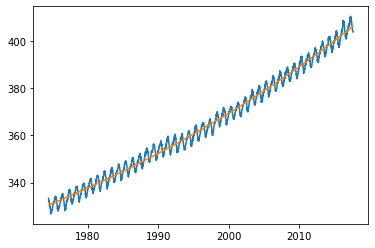

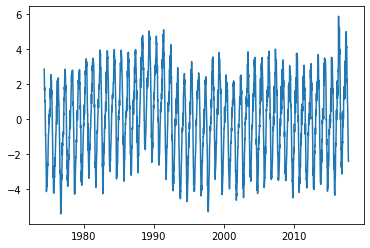

In [12]:
def my_exp(t, exponent, factor, offset):
    return offset + factor*sp.exp(t*exponent)

p0=[1e-1, 1, 310]

# now do the fit
fit_exp = curve_fit(my_exp, year-year[0], CO2, p0=p0)

print(fit_exp)
# recreate the fitted curve using the optimized parameters
data_fit_exp = my_exp(year-year[0], *fit_exp[0])

plt.plot(year,CO2)
plt.plot(year,data_fit_exp)

plt.show()
plt.plot(year,CO2-data_fit_exp)
plt.show()

<div style="background-color: #FFF8C6">
### Example: scanning experiment fitting

In [ ]:
x = sp.array([ 100.,  101.,  102.,  103.,  104.,  105.,  106.,  107.,  108.,
        109.,  110.,  111.,  112.,  113.,  114.,  115.,  116.,  117.,
        118.,  119.,  120.,  121.,  122.,  123.,  124.,  125.,  126.,
        127.,  128.,  129.,  130.,  131.,  132.,  133.,  134.,  135.,
        136.,  137.,  138.,  139.,  140.,  141.,  142.,  143.,  144.,
        145.,  146.,  147.,  148.,  149.])
y = sp.array([ 49.62351587,  53.28471702,  70.91469338,  59.347993  ,
        68.14021339,  47.96831052,  46.27111237,  47.75670421,
        54.27684285,  49.79369344,  41.06072665,  43.95823631,
        47.32189537,  57.59658829,  45.18881389,  56.58866369,
        50.1240723 ,  42.6683265 ,  41.92068127,  25.85132307,
        46.60808952,  38.07772697,  56.7941344 ,  72.65808868,
        54.94790233,  84.97532661,  82.91663574,  54.97400141,
        33.05466879,  31.07916615,  30.20075973,  23.87661428,
        21.81024528,  28.83273888,  17.92903416,  27.57351836,
        25.05685919,  27.4866161 ,  31.13142432,  20.26710321,
        16.80327091,  14.1787744 ,  20.52320243,  22.65700337,
        16.23164708,  11.78551076,  15.21441115,  12.58749491,
        12.88956241,   6.24572757])
y_error = sp.array([ 7.74596669,  7.68114575,  7.61577311,  7.54983444,  7.48331477,
        7.41619849,  7.34846923,  7.28010989,  7.21110255,  7.14142843,
        7.07106781,  7.        ,  6.92820323,  6.85565464,  6.78233068,
        6.70821365,  6.63335528,  6.55833372,  6.48664491,  6.43341394,
        6.44498198,  6.61337546,  7.02586908,  7.63076491,  8.17847123,
        8.36660027,  8.05527104,  7.36400523,  6.58504642,  5.97802099,
        5.61585191,  5.42114516,  5.29873213,  5.1972821 ,  5.09915702,
        5.00001304,  4.89898045,  4.79583158,  4.69041576,  4.5825757 ,
        4.47213596,  4.35889894,  4.24264069,  4.12310563,  4.        ,
        3.87298335,  3.74165739,  3.60555128,  3.46410162,  3.31662479])

plt.errorbar(x, y, y_error, fmt='o',capsize=2)
plt.xlabel('scan value')
plt.ylabel('signal')
plt.title('Scan experiment data')
plt.show()

<div style="background-color: #FFF8C6">
** Exercise: use the <span style="color:blue">curve_fit()</span> function to fit a straight line for the background and a Gaussian function for the feature. Hence, find the amplitude and width of the Gaussian feature. Note that in this case it is not a good idea to fit the line first and afterwards the Gaussian from the residuals, as the Gaussian will influence the line fit. Instead, fit both background and the Gaussian feature at once.**

In [ ]:
##################################################
# A program to fit the background and gaussian bump
# for the exercise 
###################################################

#Note that students have not yet learned how to create a function from scratch, 
#so I expect they will need some help to edit the 'my_sin' example from above.

def fit_func(x,a,mu,sig,m,c):
    gaus = a*sp.exp(-(x-mu)**2/(2*sig**2))
    line = m*x+c
    return gaus + line

initial_guess=[10,120,10,-2,100]
po,po_cov=sp.optimize.curve_fit(fit_func,x,y,initial_guess,y_error)

#print("The parameters")
#print(po)
#print('The covariance matrix')
#print(po_cov)

print("The signal parameters are")
print(" Gaussian amplitude = %.1f +/- %.1f" %(po[0],sp.sqrt(po_cov[0,0])))
print(" mu = %.1f +/- %.1f"%(po[1],sp.sqrt(po_cov[1,1])))
print(" Gaussian width (sigma) = %.1f +/- %.1f"%(po[2],sp.sqrt(po_cov[2,2])))
print("and the background estimate is")
print(" m = %.2f +/- %.2f"%(po[3],sp.sqrt(po_cov[3,3])))
print(" c = %.0f +/- %.0f"%(po[4],sp.sqrt(po_cov[4,4])))

plt.plot(x,fit_func(x,po[0],po[1],po[2],po[3],po[4]),label='Fit results')
plt.errorbar(x,y,yerr=y_error, fmt='o',label="Input Data",capsize=2)
plt.xlabel("A controlled parameter over which you can scan")
plt.ylabel("A measured physical quantity with an error")
plt.legend()

plt.show()